In [2]:
from ogb.linkproppred import LinkPropPredDataset

/Users/tungvuduc/opt/anaconda3/envs/dlbio_arm64/lib/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/Users/tungvuduc/opt/anaconda3/envs/dlbio_arm64/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from contextlib import contextmanager
import torch

@contextmanager
def patch_torch_load():
    original = torch.load
    torch.load = lambda f, *args, **kwargs: original(f, *args, weights_only=False, **kwargs)
    try:
        yield
    finally:
        torch.load = original

with patch_torch_load():
    dataset = LinkPropPredDataset(name="ogbl-ddi")
    data_split = dataset.get_edge_split()


In [4]:
from typing import Any

print("The graph attribute contains the following keys:")
keys = dataset.graph.keys()
print(list(keys))
print("")

# let's inspect each key
print(list[Any](keys)[0], "contains:")
print(dataset.graph["edge_index"].shape)

print("")
print(list[Any](keys)[1], "contains:")
print(dataset.graph["edge_feat"])

print("")
print(list[Any](keys)[2], "contains:")
print(dataset.graph["node_feat"])

print("")
print(list[Any](keys)[3], "contains:")
print(dataset.graph["num_nodes"])

print("")
n_nodes = dataset.graph["num_nodes"]
n_edges = dataset.graph["edge_index"].shape[1]
print(f"The graph contains {n_nodes} number of nodes and {n_edges} number of edges")

The graph attribute contains the following keys:
['edge_index', 'edge_feat', 'node_feat', 'num_nodes']

edge_index contains:
(2, 2135822)

edge_feat contains:
None

node_feat contains:
None

num_nodes contains:
4267

The graph contains 4267 number of nodes and 2135822 number of edges


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
edge_indices = dataset.graph["edge_index"]

# check for duplicate edge indices
sorted_edge_indices = np.sort(edge_indices, axis=0)
unique_edge_indices = np.unique(sorted_edge_indices, axis=1)
n_unique_edge = unique_edge_indices.shape[1]
print(f"There are {n_edges - n_unique_edge} duplicate indices")

There are 1067911 duplicate indices


Text(0.5, 0, 'edge index')

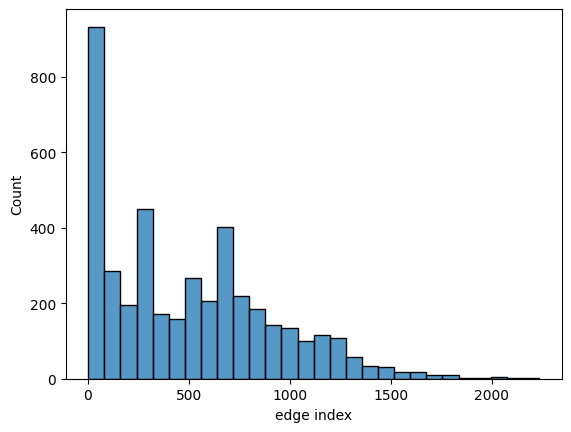

In [7]:
# let's check the number of 
n_edges_per_drug = n_edges_per_drug = np.bincount(edge_indices.flatten())
sns.histplot(n_edges_per_drug/2) # due to duplicate pairs of indices
plt.xlabel("edge index")

In [8]:
# let's compute the density of the graph
n_all_possible_edges = n_nodes * (n_nodes - 1)/2
density = n_unique_edge/n_all_possible_edges
print(f"The density of the graph is {density}")

The density of the graph is 0.11733337464515507


In [9]:
# let's check the number of train, valid and test data
train_edge_indices = data_split["train"]["edge"]

valid_pos_edge_indices = data_split["valid"]["edge"]
valid_neg_edge_indices = data_split["valid"]["edge_neg"]

test_pos_edge_indices = data_split["test"]["edge"]
test_neg_edge_indices = data_split["test"]["edge_neg"]

print(f"Numbers of train positive edges {train_edge_indices.shape[0]}")
print(f"Numbers of valid positive edges {valid_pos_edge_indices.shape[0]}")
print(f"Numbers of valid negative edges {valid_neg_edge_indices.shape[0]}")
print(f"Numbers of test positive edges {test_pos_edge_indices.shape[0]}")
print(f"Numbers of test negative edges {test_neg_edge_indices.shape[0]}")


Numbers of train positive edges 1067911
Numbers of valid positive edges 133489
Numbers of valid negative edges 101882
Numbers of test positive edges 133489
Numbers of test negative edges 95599


In [10]:
# let's check if the setting is transductive (test and valid drugs are in the train data) or inductive (test and valid drugs are not in the train data)
unique_train_indices = np.unique(train_edge_indices)

unique_valid_pos_indices = np.unique(valid_pos_edge_indices)
unique_valid_neg_indices = np.unique(valid_neg_edge_indices)

unique_test_pos_indices = np.unique(test_pos_edge_indices)
unique_test_neg_indices = np.unique(test_neg_edge_indices)

valid_in_train = np.isin(unique_valid_pos_indices, train_edge_indices).all()
test_in_train = np.isin(unique_test_pos_indices, train_edge_indices).all()

if valid_in_train & test_in_train:
    print("The setting is transductive")
else:
    print("The setting is inductive")

The setting is transductive


In [11]:
import pandas as pd

ddi_descriptions = pd.read_csv("/Users/tungvuduc/Desktop/private.projects/ogb.ddi/dataset/ogbl_ddi/mapping/ddi_description.csv.gz")
nodeidx2drugid = pd.read_csv("/Users/tungvuduc/Desktop/private.projects/ogb.ddi/dataset/ogbl_ddi/mapping/nodeidx2drugid.csv.gz")

In [12]:
# let't prepare the DatasetBuilder class
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected
from typing import Optional

class DatasetBuilder:

    def __init__(self, path):
        self.path = path
    
    @contextmanager
    def patch_torch_load(self):
        original = torch.load
        torch.load = lambda f, *args, **kwargs: original(f, *args, weights_only=False, **kwargs)
        try:
            yield
        finally:
            torch.load = original

    def build(self):
        None

    def prepare_pairs(self):
        None

    def infer_negative_pairs(self):
        None

    def subset(self, dataset_splits: dict, rng: torch.Generator, node_limit: int, keep_original_ids: bool) -> dict[str, torch.tensor]:

        node_ids = torch.randperm(dataset_splits["train"].n_nodes, generator=rng)[:node_limit]
        dataset_subset_split = {}

        for name, dataset in dataset_splits.items():
            dataset_subset_split[name] = dataset.subset(node_ids, keep_original_ids)

        return dataset_subset_split

    def prepare_graph(
        self,
        n_nodes: int,
        pos_pairs: torch.Tensor,
        subset: Optional[int] = None,
    ) -> Data:
        
        if subset is not None:
            assert subset <= n_nodes, f"subset ({subset}) cannot exceed n_nodes ({n_nodes})"
            mask = (pos_pairs[0] < subset) & (pos_pairs[1] < subset)
            pos_pairs = pos_pairs[:, mask]
            n_nodes = subset

        edge_index = to_undirected(pos_pairs).contiguous()

        return Data(edge_index=edge_index, num_nodes=n_nodes)

    def prepare_annotation(self) -> pd.DataFrame:

        ddi_path = f"{self.path}/ogbl_ddi/mapping/ddi_description.csv.gz"
        ddi_descriptions = pd.read_csv(ddi_path)

        node_to_dbid_lookup_path = f"{self.path}/ogbl_ddi/mapping/nodeidx2drugid.csv.gz"
        node_to_dbid_lookup = pd.read_csv(node_to_dbid_lookup_path)

        first_drug = ddi_descriptions.loc[:, ["first drug id", "first drug name"]].rename({"first drug id":"dbid", "first drug name":"drug name"}, axis=1)
        second_drug = ddi_descriptions.loc[:, ["second drug id", "second drug name"]].rename({"second drug id":"dbid", "second drug name":"drug name"}, axis=1)

        dbid_to_name_lookup = pd.concat(
            [first_drug, second_drug]
        ).drop_duplicates().reset_index(drop=True)

        annotation = pd.merge(
            node_to_dbid_lookup.rename(
                {
                    "drug id": "dbid"
                }, axis=1
            ),
            dbid_to_name_lookup,
            how="inner",
            on="dbid"
        )

        return annotation

    def download(self) -> tuple[int, dict[str, torch.Tensor]]:
        with patch_torch_load():
            raw = LinkPropPredDataset(name="ogbl-ddi", root=self.path)
            split_pairs = raw.get_edge_split()
        
        n_nodes = raw[0]["num_nodes"]
        split_pairs["train"]["edge_neg"] = None # placeholder for negative edges.

        return n_nodes, split_pairs

# let's try out the DatasetBuilder
path = "/Users/tungvuduc/Desktop/private.projects/ogb.ddi/dataset"
datasetbuilder = DatasetBuilder(path=path)
n_nodes, split_pairs = datasetbuilder.download()
annotation = datasetbuilder.prepare_annotation()

edge_index_torch = torch.from_numpy(edge_indices).to(torch.int)
graph = datasetbuilder.prepare_graph(n_nodes, edge_index_torch)

In [13]:
from torch_geometric.utils import scatter
import torch.nn as nn

class SAGEConvLayer(nn.Module):

    def __init__(self, dropout_rate: float, embedding_dim: int, with_self: bool, degree_norm: bool):
        """GraphSage conv layer"""
        super().__init__()

        self.sage_conv = SAGEConv(embedding_dim=embedding_dim, with_self=with_self, degree_norm=degree_norm)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.relu = nn.ReLU()
    
    def forward(self, graph, x):
        x = self.sage_conv(x=x, graph=graph)
        x = self.relu(x)
        x = self.dropout(x)
        return x

class SAGEConv(nn.Module):

    def __init__(self, embedding_dim: int, with_self: bool, degree_norm: bool):
        """GraphSAGE convolutional layer with optional self-loops."""
        super().__init__()
        
        self.embedding_dim = embedding_dim
        self.with_self = with_self
        self.degree_norm = degree_norm

        self.linear = nn.Linear(embedding_dim*2, embedding_dim)

    def forward(self, graph: Data, x:torch.Tensor) -> torch.Tensor:
        n_nodes = self.get_n_nodes(graph=graph)
        if self.with_self:
            senders, receivers = self._add_self_edges(graph=graph, n_nodes=n_nodes)
        else:
            senders, receivers = graph.edge_index[0], graph.edge_index[1]

        if not self.degree_norm:
            x_updated = scatter(x[senders], receivers, dim=0, reduce="mean", dim_size=n_nodes)
        
        else:
            send_degree = self._get_degree(n=senders, n_nodes=n_nodes)
            x_updated = self.normalize_by_degree(x=x, degree=send_degree)
            x_updated = scatter(x_updated[senders], receivers, dim=0, reduce="mean", dim_size=n_nodes)
            rec_degree = self._get_degree(n=receivers, n_nodes=n_nodes)
            x_updated = self.normalize_by_degree(x=x_updated, degree=rec_degree)
        
        x_updated = torch.concat([x, x_updated], dim=1)
        return self.linear(x_updated)
    
    @staticmethod
    def _get_degree(n: torch.Tensor, n_nodes: torch.Tensor):
        return torch.bincount(n, minlength=n_nodes)

    @staticmethod
    def _add_self_edges(graph: Data, n_nodes: int) -> tuple[torch.Tensor, torch.Tensor]:
        """Add self-loops to the graph"""
        senders = graph.edge_index[0]
        receivers = graph.edge_index[1]
        all_nodes = torch.arange(n_nodes)
        senders = torch.concat([senders, all_nodes])
        receivers = torch.concat([receivers, all_nodes])
        return senders, receivers

    @staticmethod
    def normalize_by_degree(x: torch.Tensor, degree: torch.Tensor):
        """Normalize the node feature by the squre-root of degree"""
        return x * torch.rsqrt(torch.clamp(degree.float(), min=1.0))[:, None]

    @staticmethod
    def get_n_nodes(graph: Data):
        return graph.num_nodes

In [14]:
# let's generate a class for node embedding
import torch.nn as nn
import torch.nn.init as init

class NodeEncoder(nn.Module):
    def __init__(self, n_nodes, embedding_dim: int, last_layer_self: bool=False, degree_norm: bool=False, dropout_rate: float=0.0):
        """Encodes nodes into embeddings using a two-layer GraphSAGE model. Returns the nodes' embedding"""
        super().__init__()
        self.n_nodes = n_nodes
        self.embedding_dim = embedding_dim
        self.last_layer_self = last_layer_self
        self.degree_norm = degree_norm
        self.dropout_rate = dropout_rate

        self.embedding = nn.Embedding(num_embeddings=self.n_nodes, embedding_dim=self.embedding_dim)
        init.xavier_uniform_(self.embedding.weight)

        self.sage_conv_layer = SAGEConvLayer(dropout_rate=self.dropout_rate, embedding_dim=self.embedding_dim, with_self=True, degree_norm=self.degree_norm)
        self.sage_conv_out = SAGEConv(embedding_dim=self.embedding_dim, with_self=self.last_layer_self, degree_norm=self.degree_norm)

    def forward(self, graph: Data):
        x = self.embedding(graph.n_id)
        x = self.sage_conv_layer(graph=graph, x=x)
        x = self.sage_conv_out(graph=graph, x=x)
        return x

In [ ]:
class LinkPredictor(nn.Module):
    """Scores node pairs based to predict presence and absence of an edge"""
    def __init__(self, embedding_dim: int, dropout_rate: float, n_layers: float):
        super().__init__()

        self.mlp = LinkPredictorLayer(embedding_dim=embedding_dim, n_layers=n_layers, dropout_rate=dropout_rate)

    def forward(self, sender_embeddings, receiver_embeddings):

        x = sender_embeddings * receiver_embeddings
        x = self.mlp(x)

        return x.squeeze()

class LinkPredictorLayer(nn.Module):
    """Layers for the LinkPredictor"""
    def __init__(self, embedding_dim: int, n_layers: int, dropout_rate: float):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.n_layers = n_layers
        self.dropout_rate = dropout_rate

        layers = []
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(embedding_dim, embedding_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))

        layers.append(nn.Linear(embedding_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x: torch.tensor):
        return self.mlp(x)

In [24]:
class GraphSAGEDrugInteractionModel(nn.Module):
    """Graph NN to predict interaction between drugs"""

    def __init__(self, n_nodes: int, embedding_dim: int, last_layer_self: bool, degree_norm: bool, dropout_rate: float, n_layers: int):
        super().__init__()
        self.node_encoder = NodeEncoder(
            n_nodes=n_nodes, 
            embedding_dim=embedding_dim, 
            last_layer_self=last_layer_self, 
            degree_norm=degree_norm, 
            dropout_rate=dropout_rate
            )
        self.link_predictor = LinkPredictor(
            embedding_dim=embedding_dim, 
            dropout_rate=dropout_rate, 
            n_layers=n_layers)

    def encode(self, graph: Data):
        return self.node_encoder(graph=graph)

    def decode(self, encoded: torch.tensor, edge_label_index: torch.tensor):
        return self.link_predictor(
            sender_embeddings=encoded[edge_label_index[0]],
            receiver_embeddings=encoded[edge_label_index[1]]
            )

In [ ]:
from torch_geometric.loader import LinkNeighborLoader

path = "/Users/tungvuduc/Desktop/private.projects/ogb.ddi/dataset"
datasetbuilder = DatasetBuilder(path=path)

n_nodes, split_pairs = datasetbuilder.download()

edge_index = dataset.graph["edge_index"]
edge_index = torch.from_numpy(edge_indices).to(torch.long)
graph = datasetbuilder.prepare_graph(n_nodes=n_nodes, pos_pairs=edge_index, subset=50)
loader = LinkNeighborLoader(
    data=graph,
    num_neighbors=[20, 10],
    edge_label_index=graph.edge_index,
    edge_label=torch.ones(graph.edge_index.size(1)),
    neg_sampling_ratio=1.0,
    batch_size=16,
    shuffle=True
)

In [49]:
model = GraphSAGEDrugInteractionModel(n_nodes=50, embedding_dim=64, last_layer_self=True, degree_norm=True, dropout_rate=0.1, n_layers=2)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

for epoch in range(100):
    model.train()
    total_loss = 0

    for batch in loader:
        optimizer.zero_grad()

        # encode: get node embeddings via GraphSAGE on subgraph
        z = model.encode(batch)

        # decode: score the candidate (u,v) pairs
        scores = model.decode(z, batch.edge_label_index)
        loss = criterion(scores, batch.edge_label)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch:03d} | Loss: {avg_loss:.4f}")


Epoch 000 | Loss: 0.6929
Epoch 001 | Loss: 0.6874
Epoch 002 | Loss: 0.6513
Epoch 003 | Loss: 0.5739
Epoch 004 | Loss: 0.5375
Epoch 005 | Loss: 0.5389
Epoch 006 | Loss: 0.5242
Epoch 007 | Loss: 0.4717
Epoch 008 | Loss: 0.5343
Epoch 009 | Loss: 0.4922
Epoch 010 | Loss: 0.4858
Epoch 011 | Loss: 0.4776
Epoch 012 | Loss: 0.4517
Epoch 013 | Loss: 0.4409
Epoch 014 | Loss: 0.4498
Epoch 015 | Loss: 0.4409
Epoch 016 | Loss: 0.4472
Epoch 017 | Loss: 0.4044
Epoch 018 | Loss: 0.4092
Epoch 019 | Loss: 0.4422
Epoch 020 | Loss: 0.4217
Epoch 021 | Loss: 0.4211
Epoch 022 | Loss: 0.4151
Epoch 023 | Loss: 0.4085
Epoch 024 | Loss: 0.4072
Epoch 025 | Loss: 0.3923
Epoch 026 | Loss: 0.3862
Epoch 027 | Loss: 0.4063
Epoch 028 | Loss: 0.3742
Epoch 029 | Loss: 0.4218
Epoch 030 | Loss: 0.3926
Epoch 031 | Loss: 0.4149
Epoch 032 | Loss: 0.3897
Epoch 033 | Loss: 0.3412
Epoch 034 | Loss: 0.4040
Epoch 035 | Loss: 0.3736
Epoch 036 | Loss: 0.3899
Epoch 037 | Loss: 0.3752
Epoch 038 | Loss: 0.3811
Epoch 039 | Loss: 0.3588


In [44]:
total_loss

7.116948902606964